### Importing Libraries

In [1]:
import sys
import time
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.data import from_pandas
from mlflow.tracking import MlflowClient
from mlflow.models import infer_signature

from churnlabs.core.config import PROJECT_ROOT

### Warnings Configuration

In [2]:
# Suppress MLflow Warnings Only
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")
warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")

### MLflow Configuration

In [3]:
# This sets the tracking URI for MLflow
# Instead of using the default local ./mlruns folder,
# It configure MLflow to use a SQLite database stored inside the project directory
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}")

### Custom Seaborn Plot Style

In [4]:
# This snippet allow us to create a custom style of plots in Seaborn
sns.set_style('ticks')
sns.set_theme('paper')

### Importing Parquet Data

In [5]:
from churnlabs.data.loaders import load_processed_data
churn_data = load_processed_data()
churn_data.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.850000,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950001,1889.500000,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.849998,108.150002,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.299999,1840.750000,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.699997,151.649994,Yes


### Copy of Original DataFrame

In [6]:
# Making a copy of Original DataFrame
df = churn_data.copy()

### Splitting the Data

In [7]:
# Splitting Data into Training and Testing Set
from churnlabs.features.split import split_data
X_train, X_test, y_train, y_test = split_data(df)

### Encoding Target Variable

In [8]:
# Encoding Target Variable (Yes/No -> 1/0)
from churnlabs.models.encoder import target_encoder
y_train, y_test = target_encoder(y_train, y_test)

### Creating a Pipeline

In [9]:
# Importing Libraries
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
# Importing Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [11]:
# Transformation for Categorical Columns
cat_cols = X_train.select_dtypes(include='category').columns

cat_trf = Pipeline(steps=[
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'))
])

In [12]:
# Transformation for Numerical Columns
num_cols = [col for col in X_train.select_dtypes(include='number').columns if col != 'seniorcitizen']

num_trf = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [13]:
# Column Transformation
ctf = ColumnTransformer(transformers=[
    ('categorical', cat_trf, cat_cols),
    ('numerical', num_trf, num_cols)
], remainder='passthrough', n_jobs=-1)

In [14]:
# Importing DummyClassifier Model
dummy = DummyClassifier(strategy='most_frequent', random_state=42)

In [15]:
# Pipeline
pipe = Pipeline(steps=[
    ('preprocessor', ctf),
    ('model', dummy)
])

In [16]:
# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
# Cross-Validation
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv = cross_validate(estimator=pipe, X=X_train, y=y_train, cv=skf, scoring=scoring, n_jobs=-1)

In [18]:
# Cross Validation Result
results = {metric.replace('test_', ''): [np.mean(scores), np.std(scores)] for metric, scores in cv.items() if metric.startswith('test')}
results_df = pd.DataFrame(results, index=['mean', 'std']).T
results_df

,mean,std
accuracy,0.734222,0.0
precision,0.000000,0.0
recall,0.000000,0.0
f1,0.000000,0.0
roc_auc,0.500000,0.0
pr_auc,0.265778,0.0


**What `DummyClassifier` helps us check?**
- The `DummyClassifier` gives us a basic baseline to compare against real models.
- It predicts the majority class (`non-churn`) for every customer.
```
# Class Distribution
churn
No     0.7342
Yes    0.2657
```
```
# Classification Metrics
accuracy    73%
precision   0
recall      0
f1          0
roc-auc     0.5
pr-auc      0.26
```
- Since the dataset contains approximately 73% non-churn customers, the model achieves 73% accuracy.
- However, it fails to identify any churners, resulting in zero precision, recall, and F1 score.
- The ROC AUC of 0.5 confirms that the model has no predictive power and performs equivalent to random guessing.
- The `DummyClassifier` makes exactly the same prediction in every fold.
- So every fold produces identical metrics, and that's why standard deviation is equal to 0.
- This confirms our pipeline and cross-validation setup behave as expected and no obvious leakage exists.
- Now any real model must surpass this benchmark to be considered a good performer.
```
# Real Model Expectations
Achieve PR AUC > 0.26
Achieve ROC AUC > 0.5
Achieve Precision > 0
Achieve Recall > 0
Achieve F1 Score > 0
```
- If a trained model cannot outperform this baseline, it is not useful.

---

### Model Comparison MLflow Experiment

In [19]:
# Define the name of the MLflow Experiment
experiment_name = 'model_comparison'

# Define the location of Model Artifacts and Dataset
artifact_location = PROJECT_ROOT / 'mlartifacts'
dataset_location = PROJECT_ROOT / 'data' / 'processed' / 'customer-churn-clean.parquet'

# Experiment-level Metadata
experiment_tags = {
    'project': 'customer_churn_prediction',
    'problem_type': 'binary_classification',
    'business_metric': 'recall',
    'validation_strategy': 'stratified_5_fold',
    'dataset_path': str(dataset_location),
    'stage': 'experimentation',
    'python_version': sys.version.split()[0],
    'os': platform.system()
}

# Check if the experiment already exists, and create the experiment if it doesn't exist
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=experiment_name,
        artifact_location=f"file:///{artifact_location}",
        tags=experiment_tags
    )
else:
    experiment_id = experiment.experiment_id

# Set as Active Experiment, where all subsequent mlflow.start_run() calls will be logged under this experiment
mlflow.set_experiment(experiment_name)

2026/04/09 09:42:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/09 09:42:31 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///C:\\Users\\iamri\\Videos\\Projects\\churnlabs\\mlartifacts', creation_time=1775707954065, experiment_id='1', last_update_time=1775707954065, lifecycle_stage='active', name='model_comparison', tags={'business_metric': 'recall',
 'dataset_path': 'C:\\Users\\iamri\\Videos\\Projects\\churnlabs\\data\\processed\\customer-churn-clean.parquet',
 'os': 'Windows',
 'problem_type': 'binary_classification',
 'project': 'customer_churn_prediction',
 'python_version': '3.11.14',
 'stage': 'experimentation',
 'validation_strategy': 'stratified_5_fold'}, workspace='default'>

In [20]:
# Initialize MLflow client
client = MlflowClient()

# Experiment Description (Visible in MLflow UI)
experiment_description = """
**Experiment**
- Model Comparison

**Objective**
- Evaluate and compare multiple machine learning models for predicting customer churn.

**Evaluation Metrics**
- Accuracy
- Precision
- Recall (Business Metric)
- F1 Score
- ROC-AUC
"""

# Attach Experiment Description
client.set_experiment_tag(
    experiment_id,
    'mlflow.note.content',
    experiment_description.strip()
)

In [21]:
# Multi-Model Dictionary 
models = {
    'dummy_classifier': DummyClassifier(strategy='most_frequent', random_state=42),
    'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'k_neighbors_classifier': KNeighborsClassifier(n_jobs=-1),
    'support_vector_classifier': SVC(class_weight='balanced', probability=True, random_state=42),
    'decision_tree_classifier': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'random_forest_classifier': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'gradient_boosting_classifier': GradientBoostingClassifier(random_state=42)
}

In [22]:
# Dictionary to store aggregated CV results for all models
final_results = {}

# Loop through each model defined in the models dictionary
for name, model in models.items():

    # Start a new MLflow run for each model
    with mlflow.start_run(
        run_name=name,
        description=f"MLflow run for '{name}' using StratifiedKFold Cross-validation",
        tags={
            'project': 'customer_churn_prediction',
            'phase': 'experimentation',
            'experiment_type': 'model_comparison',
            'problem_type': 'binary_classification',
            'business_metric': 'recall'
        },
        log_system_metrics=True
    ):

        # Log Dataset Information
        dataset = from_pandas(
            churn_data,
            source=str(dataset_location),
            name='customer_churn_data',
            targets='churn',
        )
        
        mlflow.log_input(dataset, context='training')

        mlflow.log_param('dataset_name', 'customer_churn_data')
        mlflow.log_param('dataset_rows', len(X_train))
        mlflow.log_param('dataset_features', X_train.shape[1])
        mlflow.log_param('target_variable', 'churn')

        # Build Pipeline
        pipe = Pipeline(steps=[
            ('preprocessor', ctf),
            ('model', model)
        ])

        # Cross Validation
        start_time = time.time()
        
        cv = cross_validate(
            estimator=pipe,
            X=X_train,
            y=y_train,
            cv=skf,
            scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision'],
            n_jobs=-1
        )

        runtime = time.time() - start_time
        mlflow.log_metric('cv_runtime_sec', runtime)
        
        # Log Fold Metrics
        for metric, scores in cv.items():
            if metric.startswith('test_'):
                metric_name = metric.replace('test_', '').replace('average_precision', 'pr_auc')
        
                for fold_idx, score in enumerate(scores):
                    mlflow.log_metric(
                        key=f"{metric_name}_fold",
                        value=score,
                        step=fold_idx
                    )

        # Log Aggregated Metrics
        results = {}

        for metric, scores in cv.items():
            if metric.startswith('test_'):
                metric_name = metric.replace('test_', '').replace('average_precision', 'pr_auc')

                mean_score = np.mean(scores)
                std_score = np.std(scores)

                results[f"{metric_name}_mean"] = mean_score
                results[f"{metric_name}_std"] = std_score

                mlflow.log_metric(f"{metric_name}_mean", mean_score)
                mlflow.log_metric(f"{metric_name}_std", std_score)

        final_results[name] = results

        # Log Model Info
        mlflow.log_param('model_type', model.__class__.__name__)
        mlflow.log_param('random_state', 42)
        mlflow.log_param('cv_folds', 5)

        for param_name, param_value in model.get_params().items():
                if isinstance(param_value, (int, float, str, bool)):
                    mlflow.log_param(param_name, param_value)

        # Log Each Fitted Model
        pipe.fit(X_train, y_train)

        X_train_for_mlflow = X_train.copy()

        int_cols = X_train_for_mlflow.select_dtypes(include=['int64']).columns
        X_train_for_mlflow[int_cols] = X_train_for_mlflow[int_cols].astype('float64')
    
        signature = infer_signature(X_train_for_mlflow, pipe.predict(X_train_for_mlflow))
        input_example = X_train_for_mlflow.iloc[:5]
        
        mlflow.sklearn.log_model(
            sk_model=pipe,
            name=name,
            serialization_format='cloudpickle',
            signature=signature,
            input_example=input_example,
            metadata={
                'problem_type': 'binary_classification',
                'target': 'churn',
                'business_metric': 'recall',
                'cv_folds': 5,
            },
            tags={
                'model_family': model.__class__.__name__,
                'project': 'customer_churn_prediction',
            },
            model_type='sklearn_classifier',
        )

2026/04/09 09:43:25 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:43:25 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:43:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:43:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/04/09 09:43:49 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:43:49 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/09 09:43:50 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:43:50 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:43:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:43:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/04/09 09:43:55 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:43:55 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/09 09:43:55 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:43:55 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:43:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:44:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/04/09 09:44:03 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:44:03 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/09 09:44:03 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:44:03 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:44:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:44:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/04/09 09:44:15 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:44:15 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/09 09:44:15 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:44:15 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:44:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:44:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/04/09 09:44:20 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:44:20 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/09 09:44:20 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:44:20 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:44:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:44:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/04/09 09:44:26 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:44:26 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/04/09 09:44:26 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 09:44:26 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 09:44:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 09:44:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/04/09 09:44:32 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 09:44:32 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


### Performance Evaluation using Cross-Validation

In [23]:
# Creating Logistic Regression Model Object
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [24]:
# Final Pipeline with Logistic Regression
pipe = Pipeline(steps=[
        ('preprocessor', ctf),
        ('model', lr)
    ])

In [25]:
# Cross Val Predict
y_pred_cv = cross_val_predict(estimator=pipe, X=X_train, y=y_train, cv=skf, method='predict', n_jobs=-1)

In [26]:
# Classification Report
print(classification_report(y_train, y_pred_cv, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      4130
         Yes       0.52      0.80      0.63      1495

    accuracy                           0.75      5625
   macro avg       0.72      0.77      0.72      5625
weighted avg       0.81      0.75      0.77      5625



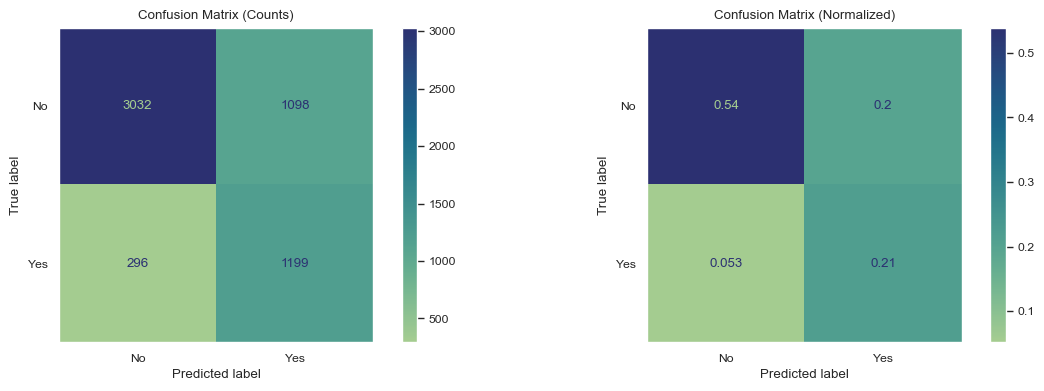

In [27]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_true=y_train, y_pred=y_pred_cv, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_true=y_train, y_pred=y_pred_cv, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix (Counts)')
ax[1].set_title('Confusion Matrix (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()

### Feature Importance

In [28]:
# Fitting Pipeline
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [29]:
# Raw Column Names from ColumnTransformer (like 'numerical__totalcharges')
raw_features = pipe.named_steps['preprocessor'].get_feature_names_out()

In [30]:
# Clean Column Names (splitting based on '__' and extracting 2nd element)
# ['numerical', 'totalcharges'] -> 'totalcharges'
features = [feature.split('__')[1] for feature in raw_features]

In [31]:
# Coefficients from Logistic Regression
coefficients = pipe.named_steps['model'].coef_[0]

In [32]:
# Feature Importance DataFrame
importance_df = pd.DataFrame({'feature': features, 'importance': coefficients}).sort_values(by='importance', ascending=False)

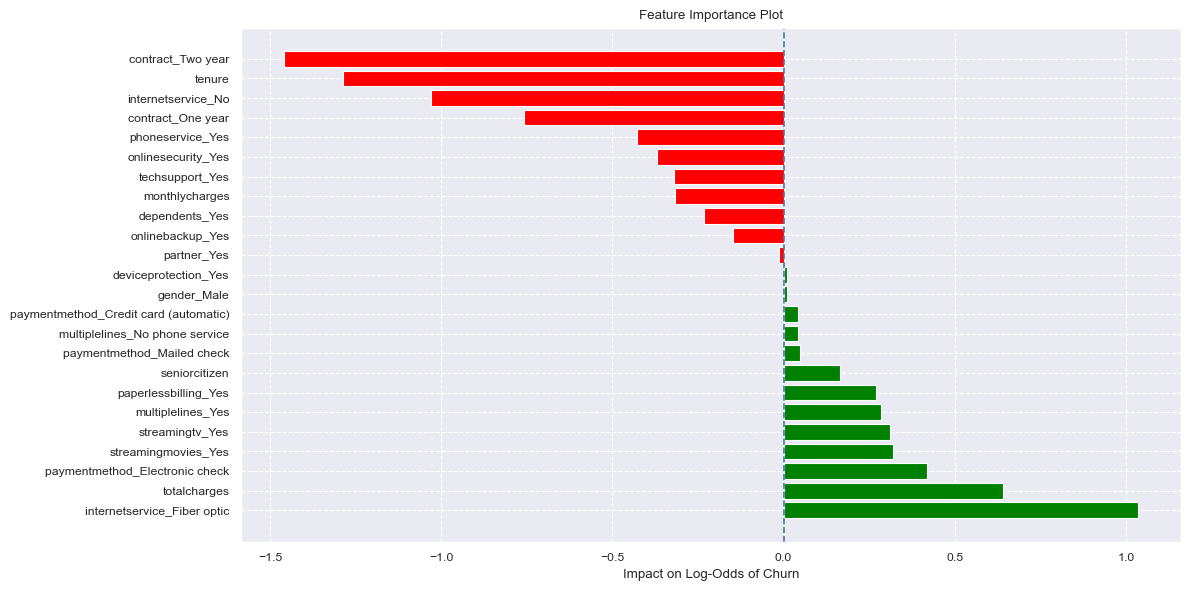

In [33]:
# Feature Importance Plot
plt.figure(figsize=(12, 6))
colors = ['green' if val > 0 else 'red' for val in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Impact on Log-Odds of Churn')
plt.title('Feature Importance Plot')
plt.axvline(0, linestyle='--')
plt.grid(axis='both', linestyle='--', alpha=1)
plt.tight_layout()
plt.show()

**Feature Importance Interpretation**
- 🟢 Positive coefficients → Increase churn risk
- 🔴 Negative coefficients → Decrease churn risk

Values represent impact on log-odds of churn.

---

### Decision Threshold Optimization

In [35]:
# Cross Val Predict
y_proba_cv = cross_val_predict(estimator=pipe, X=X_train, y=y_train, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

In [36]:
# Compute Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_train, y_proba_cv)

In [37]:
# Align Threshold with Precision/Recall
pr_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})
pr_results

,threshold,precision,recall
0,0.002810,0.265778,1.000000
1,0.003096,0.265825,1.000000
2,0.003893,0.265872,1.000000
3,0.003929,0.265920,1.000000
4,0.004024,0.265967,1.000000
...,...,...,...
5608,0.931300,1.000000,0.003344
5609,0.936510,1.000000,0.002676
5610,0.937016,1.000000,0.002007
5611,0.939324,1.000000,0.001338


In [38]:
# Define a Recall Target (Business Decision)
recall_target = 0.90

In [39]:
# Evaluate Recall across Thresholds and Choose Best Threshold
valid = pr_results[pr_results["recall"] >= recall_target]

if not valid.empty:
    best_row = valid.loc[valid["precision"].idxmax()]
    best_threshold = best_row["threshold"]
else:
    best_threshold = 0.5

print(f"Best Threshold: {best_threshold:.4f}")

Best Threshold: 0.3658


### Performance Evaluation using Cross-Validation with Tuned Threshold

In [40]:
# Best Threshold
y_pred_best = (y_proba_cv >= best_threshold).astype(int)

In [41]:
# Classification Report
print(classification_report(y_train, y_pred_best, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.94      0.61      0.74      4130
         Yes       0.45      0.90      0.60      1495

    accuracy                           0.69      5625
   macro avg       0.70      0.75      0.67      5625
weighted avg       0.81      0.69      0.70      5625



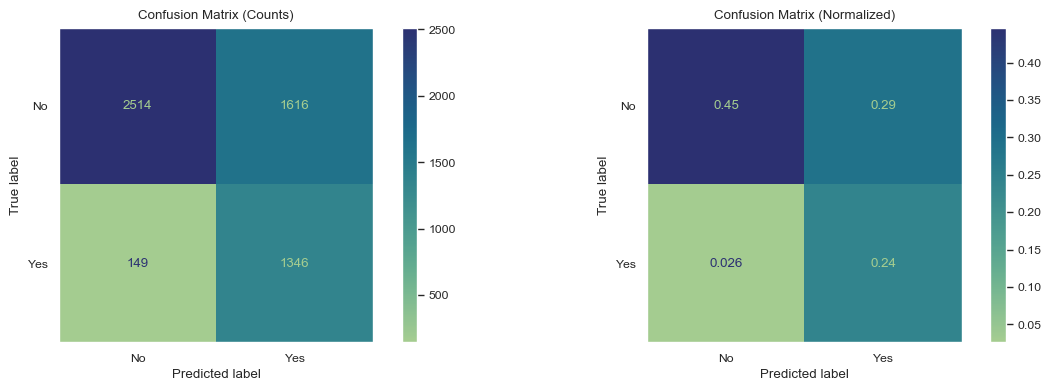

In [42]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_best, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_best, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix (Counts)')
ax[1].set_title('Confusion Matrix (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()

### Threshold Optimization MLflow Experiment

In [43]:
# Define the name of the MLflow Experiment
experiment_name = 'threshold_optimization'

# Experiment-level Metadata
experiment_tags = {
    'project': 'customer_churn_prediction',
    'problem_type': 'binary_classification',
    'business_metric': 'recall',
    'validation_strategy': 'stratified_5_fold',
    'dataset_path': str(dataset_location),
    'stage': 'threshold_optimization',
    'python_version': sys.version.split()[0],
    'os': platform.system()
}

# Check if the experiment already exists, and create the experiment if it doesn't exist
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=experiment_name,
        artifact_location=f"file:///{artifact_location}",
        tags=experiment_tags
    )
else:
    experiment_id = experiment.experiment_id

# Set as Active Experiment, where all subsequent mlflow.start_run() calls will be logged under this experiment
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///C:\\Users\\iamri\\Videos\\Projects\\churnlabs\\mlartifacts', creation_time=1775709105112, experiment_id='2', last_update_time=1775709105112, lifecycle_stage='active', name='threshold_optimization', tags={'business_metric': 'recall',
 'dataset_path': 'C:\\Users\\iamri\\Videos\\Projects\\churnlabs\\data\\processed\\customer-churn-clean.parquet',
 'os': 'Windows',
 'problem_type': 'binary_classification',
 'project': 'customer_churn_prediction',
 'python_version': '3.11.14',
 'stage': 'threshold_optimization',
 'validation_strategy': 'stratified_5_fold'}, workspace='default'>

In [44]:
# Initialize MLflow Client
client = MlflowClient()

# Experiment Description (Visible in MLflow UI)
experiment_description = """
**Experiment**
- Threshold Optimization

**Objective**
- Optimize performance of Logistic Regression Model using a recall-optimized decision threshold.

**Evaluation Metrics**
- Accuracy
- Precision
- Recall (Business Metric)
- F1 Score
- ROC-AUC
- PR-AUC
"""

# Attach Experiment Description
client.set_experiment_tag(
    experiment_id,
    'mlflow.note.content',
    experiment_description.strip()
)

2026/04/09 10:01:56 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 10:01:56 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 10:02:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 10:02:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/04/09 10:02:14 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 10:02:14 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


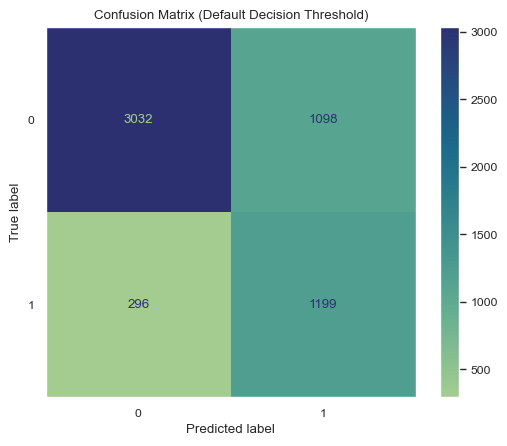

In [45]:
# Run 1 : Default Decision Threshold
with mlflow.start_run(
    run_name='default_decision_threshold',
    description='Validation run for Logistic Regression with Default Decision Threshold',
    tags={
        'project': 'customer_churn_prediction',
        'phase': 'validation',
        'threshold_type': 'default',
        'problem_type': 'binary_classification',
        'business_metric': 'recall'
    },
    log_system_metrics=True
):
    # Log Model Info
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('random_state', 42)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('decision_threshold', 0.5)

    # Log Dataset Information
    dataset = from_pandas(
        churn_data,
        source=str(dataset_location),
        name='customer_churn_data',
        targets='churn',
    )

    mlflow.log_input(dataset, context='training')

    # Build Pipeline
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

    pipe = Pipeline(steps=[
        ('preprocessor', ctf),
        ('model', lr)
    ])

    # Cross Validation
    start_time = time.time()
    
    y_proba_cv = cross_val_predict(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=skf,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    mlflow.log_metric('cv_runtime_sec', time.time() - start_time)

    # Default Threshold Metrics (0.5)
    y_pred_default = (y_proba_cv >= 0.5).astype(int)
    mlflow.log_metric('accuracy', np.mean(y_pred_default == y_train))
    mlflow.log_metric('precision', precision_score(y_train, y_pred_default))
    mlflow.log_metric('recall', recall_score(y_train, y_pred_default))
    mlflow.log_metric('f1', f1_score(y_train, y_pred_default))

    # ROC AUC (Threshold-Independent)
    mlflow.log_metric('roc_auc', roc_auc_score(y_train, y_proba_cv))
    mlflow.log_metric('pr_auc', average_precision_score(y_train, y_proba_cv))

    # Classification Reports
    report_default = classification_report(y_train, y_pred_default, target_names=['No', 'Yes'])

    with open('classification_report_default.txt', 'w') as f:
        f.write(report_default)

    mlflow.log_artifact('classification_report_default.txt', artifact_path='reports')

    # Confusion Matrix (Default Threshold)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_default, cmap='crest')
    plt.title('Confusion Matrix (Default Decision Threshold)')
    plt.grid(visible=False)
    plt.savefig('confusion_matrix_default.png')
    mlflow.log_artifact('confusion_matrix_default.png', artifact_path='plots')
    plt.close(fig)

    # Log Final Fitted Model
    pipe.fit(X_train, y_train)
    
    X_train_for_mlflow = X_train.copy()

    int_cols = X_train_for_mlflow.select_dtypes(include=['int64']).columns
    X_train_for_mlflow[int_cols] = X_train_for_mlflow[int_cols].astype('float64')

    signature = infer_signature(X_train_for_mlflow, pipe.predict(X_train_for_mlflow))
    input_example = X_train_for_mlflow.iloc[:5]  

    mlflow.sklearn.log_model(
        sk_model=pipe,
        name='logistic_regression_default_decision_threshold',
        serialization_format='cloudpickle',
        signature=signature,
        input_example=input_example,
        metadata={
                'problem_type': 'binary_classification',
                'target': 'churn',
                'business_metric': 'recall',
                'cv_folds': 5,
                'decision_threshold': 0.5
            },
            tags={
                'model_family': 'LogisticRegression',
                'project': 'customer_churn_prediction',
            },
            model_type='sklearn_classifier',
    )

2026/04/09 10:02:17 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/09 10:02:17 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/09 10:02:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/09 10:02:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/04/09 10:02:24 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/09 10:02:24 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


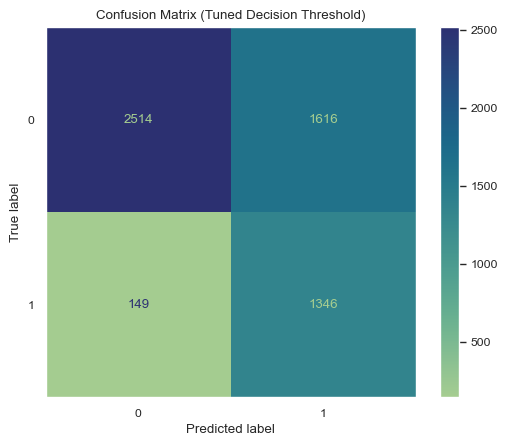

In [46]:
# Run 2 : Tuned Decision Threshold
with mlflow.start_run(
    run_name='tuned_decision_threshold',
    description='Validation run for Logistic Regression with Tuned Decision Threshold',
    tags={
        'project': 'customer_churn_prediction',
        'phase': 'validation',
        'threshold_type': 'tuned',
        'problem_type': 'binary_classification',
        'business_metric': 'recall'
    },
    log_system_metrics=True
):
    # Log Model Info
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('random_state', 42)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('decision_threshold', float(best_threshold))

    # Log Dataset Information
    dataset = from_pandas(
        churn_data,
        source=str(dataset_location),
        name='customer_churn_data',
        targets='churn',
    )

    mlflow.log_input(dataset, context='training')

    # Build Pipeline
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

    pipe = Pipeline(steps=[
        ('preprocessor', ctf),
        ('model', lr)
    ])

    # Cross Validation
    start_time = time.time()
    
    y_proba_cv = cross_val_predict(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=skf,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    mlflow.log_metric('cv_runtime_sec', time.time() - start_time)

    # Tuned Threshold Metrics
    y_pred_tuned = (y_proba_cv >= best_threshold).astype(int)
    mlflow.log_metric('accuracy', np.mean(y_pred_tuned == y_train))
    mlflow.log_metric('precision', precision_score(y_train, y_pred_tuned))
    mlflow.log_metric('recall', recall_score(y_train, y_pred_tuned))
    mlflow.log_metric('f1', f1_score(y_train, y_pred_tuned))

    # ROC AUC (Threshold-Independent)
    mlflow.log_metric('roc_auc', roc_auc_score(y_train, y_proba_cv))
    mlflow.log_metric('pr_auc', average_precision_score(y_train, y_proba_cv))

    # Classification Reports
    report_tuned = classification_report(y_train, y_pred_tuned, target_names=['No', 'Yes'])

    with open('classification_report_tuned.txt', 'w') as f:
        f.write(report_tuned)

    mlflow.log_artifact('classification_report_tuned.txt', artifact_path='reports')

    # Confusion Matrix (Tuned Threshold)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tuned, cmap='crest')
    plt.title('Confusion Matrix (Tuned Decision Threshold)')
    plt.grid(visible=False)
    plt.savefig('confusion_matrix_tuned.png')
    mlflow.log_artifact('confusion_matrix_tuned.png', artifact_path='plots')
    plt.close(fig)

    # Log Final Fitted Model
    pipe.fit(X_train, y_train)
    
    X_train_for_mlflow = X_train.copy()

    int_cols = X_train_for_mlflow.select_dtypes(include=['int64']).columns
    X_train_for_mlflow[int_cols] = X_train_for_mlflow[int_cols].astype('float64')

    signature = infer_signature(X_train_for_mlflow, pipe.predict(X_train_for_mlflow))
    input_example = X_train_for_mlflow.iloc[:5]     

    mlflow.sklearn.log_model(
        sk_model=pipe,
        name='logistic_regression_tuned_decision_threshold',
        serialization_format='cloudpickle',
        signature=signature,
        input_example=input_example,
        metadata={
                'problem_type': 'binary_classification',
                'target': 'churn',
                'business_metric': 'recall',
                'cv_folds': 5,
                'decision_threshold': float(best_threshold)
            },
            tags={
                'model_family': 'LogisticRegression',
                'project': 'customer_churn_prediction',
            },
            model_type='sklearn_classifier',
    )

### Final Model Evaluation on Test Set

In [47]:
# Fitting Pipeline on Full Training Data
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [48]:
# Evaluate Final Model once on the Test Set
y_test_proba = pipe.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

In [49]:
# Classification Report
print(classification_report(y_test, y_test_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.93      0.59      0.72      1033
         Yes       0.44      0.89      0.59       374

    accuracy                           0.67      1407
   macro avg       0.69      0.74      0.65      1407
weighted avg       0.80      0.67      0.69      1407



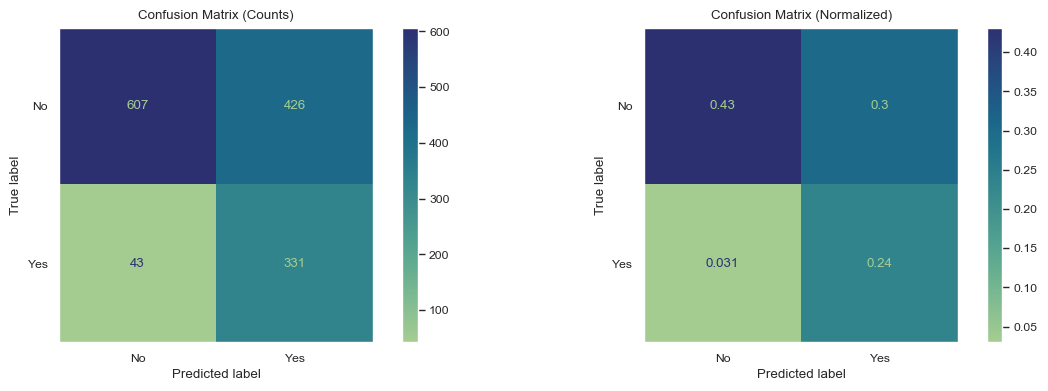

In [50]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix (Counts)')
ax[1].set_title('Confusion Matrix (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()